# CORAL-Net: Corticomuscular Ordered Regression with Aligned Latents

**Dataset:** WAY-EEG-GAL · 12 Subjects · 32-ch EEG · 5-ch EMG · 500 Hz  
**Architecture:** Learnable Causal Filterbank → Mamba State-Space Sequence Model → Differentiable Lag Alignment → Muscle Synergy Decoder  
**Objective:** Compound Electrophysiological Loss (CCC + Gated Pearson + Temporal Smoothness + Soft NMF Synergy Aux)

---

### Core NeuroAI Foundations:
1. **Zero Lookahead Guarantee:** Causal FIR depthwise filterbank initialized at physiological EEG bands (Delta: 0.5–4Hz, Alpha: 8–12Hz, Beta: 13–30Hz, Gamma: 30–80Hz).
2. **$O(T)$ Temporal Sequence Modeling:** Pure PyTorch selective state-space model (`MambaEncoder`) replacing quadratic Transformers without window boundary chunking.
3. **Differentiable Corticospinal Conduction Delay:** Continuous fractional Fourier phase modulation $\tau = \sigma(\text{logit}) \cdot 100\text{ ms}$ with zero-padding to eliminate circular wrap-around.
4. **Biological Synergy Bottleneck:** Non-negative activations $s(t) \ge 0$ and mixing matrix $W \ge 0$ warm-started via Non-Negative Matrix Factorization (NMF).
5. **Mean Collapse Immunity:** Lin's CCC loss penalizes flat-line predictions ($\mathcal{L}_{\text{CCC}} = 1.0$) while rewarding envelope morphometry and amplitude scaling.

In [4]:
# ============================================================================
# Cell 1: Environment Setup, Module Imports & Configuration
# ============================================================================
import copy
import math
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Import core modules from main
from main import (
    get_device, set_seed,
    load_participant, get_split_series,
    WAYEEGDataset, resolve_participants,
    compute_metrics, collect_predictions,
    CORALNet, LearnableFilterBank, LearnableLagAlignment,
    SynergyDecoder, extract_nmf_synergies, build_coral_net_from_config,
    CORALLoss, CCCLoss, PearsonCorrelationLoss, TemporalSmoothnessLoss,
    build_coral_loss_from_config,
    CORALTrainer, CORALTrainConfig, CORALTrainResult,
)

ROOT = Path(".")
set_seed(42)
device = get_device()
torch.backends.cudnn.benchmark = True
print(f"[INIT] Device active: {device}")

# Project Configuration for CORAL-Net
CONFIG = {
    "data": {
        "participant": "P1",
        "data_root": "data/way-eeg/raw",
        "cache_dir": "data/cache_coral_stride500",
        "window_size": 500,               # 1.0 second @ 500 Hz
        "stride": 250,                    # 0.5 second step (50% overlap)
        "fs_eeg": 500.0,
        "fs_emg": 4000.0,
        "fs_kin": 500.0,
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_features": 36,
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.5,
            "bp_high": 40.0,
            "artifact_method": "ica_auto",
            "filter_order": 4,
            "notch_freq": 50.0,
        },
        "emg": {
            "bp_low": 30.0,
            "bp_high": 300.0,
            "filter_order": 4,
            "lp_cutoff": 10.0,
            "lp_order": 2,                # ~22.8 ms causal group delay
            "downsample_factor": 8,
            "envelope_method": "rectify", # strictly causal full-wave rectification
            "causal": True,
        },
        "kinematics": {
            "include_velocity": True,
            "include_acceleration": True,
            "drop_indices": [12, 25, 38], # prune rho_GL
            "velocity_method": "sg",
            "sg_window": 11,
            "sg_poly": 3,
            "normalize": True,
        },
    },
    "model": {
        "decoder": {"out_channels": 5},
        "coral": {
            "n_synergies": 3,
            # 6 GB GPU preset (default): d_model=128, n_layers=2  ->  ~0.85 GB peak VRAM
            # 16 GB+ GPU (large):        d_model=256, n_layers=4  ->  ~3.5 GB peak VRAM
            "d_model": 128,
            "n_layers": 2,
            "d_state": 16,
            "max_lag_ms": 100.0,
            "use_kinematics": True,
            "use_checkpoint": False,    # set True on 6GB GPU to further halve activation memory
        },
    },
    "coral_loss": {
        "w_ccc": 1.0,                     # Concordance Correlation Coefficient (prevents mean collapse)
        "w_pearson": 0.5,                 # Gated Pearson correlation for phase alignment
        "w_diff": 0.2,                    # First-order temporal smoothness
        "w_rest": 0.05,                   # L1 resting baseline penalty
        "w_syn": 0.1,                     # Auxiliary soft NMF synergy guidance
        "rest_threshold": 0.15,
        "eps": 1e-6,
    },
    "training": {
        "lr": 5e-4,
        "weight_decay": 1e-2,
        "batch_size": 32,
        "epochs": 50,
        "early_stop_patience": 15,
        "grad_clip_norm": 1.0,
        "use_amp": True,
    },
}
coral_cfg = copy.deepcopy(CONFIG)


[INIT] Device active: cuda


--- VERIFYING CAUSAL FILTERBANK & IMPULSE RESPONSES ---


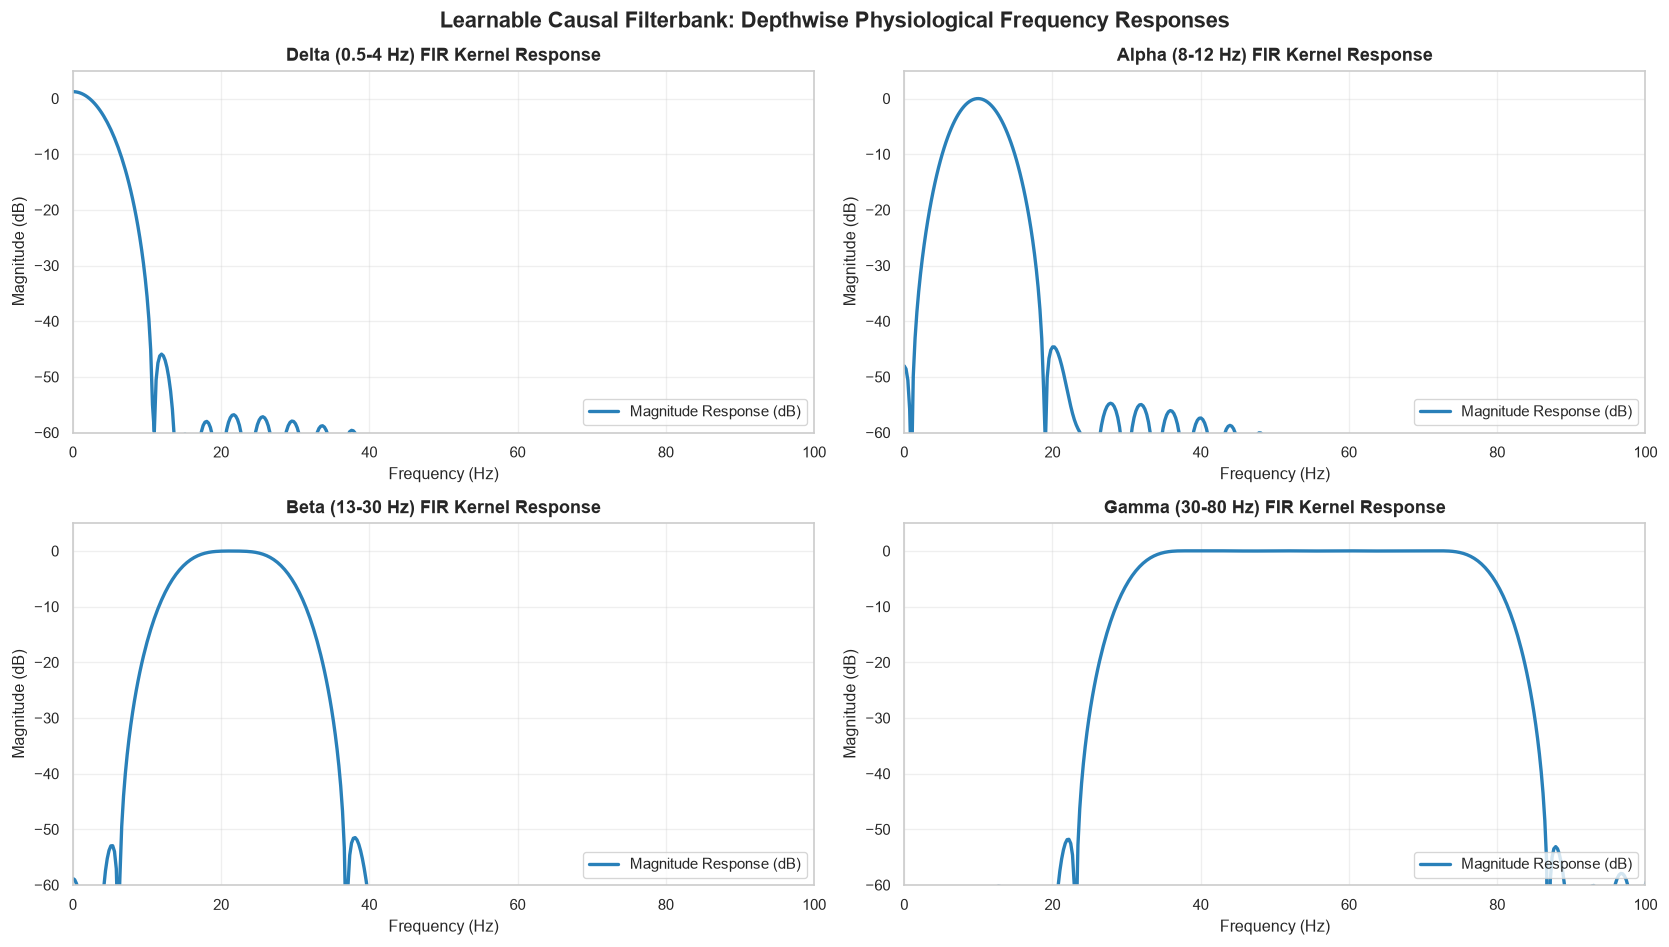

Impulse Causality Check:
  • Pre-impulse energy (t < 80):  0.00e+00 (Strictly 0.0 -> Zero Lookahead)
  • Post-impulse energy (t >= 80): 0.2004 (Active Response)
[PASS] Causal filterbank verified with zero lookahead bias.


In [5]:
# ============================================================================
# Cell 2: Causal Preprocessing & Filterbank Verification (Frequency Response)
# ============================================================================
print("--- VERIFYING CAUSAL FILTERBANK & IMPULSE RESPONSES ---")

# 1. Instantiate LearnableFilterBank
fb = LearnableFilterBank(
    in_channels=32,
    kernel_size=125,
    fs=coral_cfg["data"]["fs_eeg"],
    d_model=coral_cfg["model"]["coral"]["d_model"],
)
fb.eval()

# 2. Inspect FIR Bandpass Filter Kernels
kernel_weights = fb.depthwise_conv.weight.detach().cpu() # (128, 1, 125)
band_names = ["Delta (0.5-4 Hz)", "Alpha (8-12 Hz)", "Beta (13-30 Hz)", "Gamma (30-80 Hz)"]
fs = coral_cfg["data"]["fs_eeg"]
time_ms = np.arange(fb.kernel_size) * (1000.0 / fs)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor="white")
axes = axes.flatten()

for b_idx, b_name in enumerate(band_names):
    # Channel 0 filter kernel for this band
    k = kernel_weights[b_idx, 0, :].numpy()
    
    # Compute frequency response
    w, h = scipy.signal.freqz(k, worN=1024, fs=fs)
    mag_db = 20 * np.log10(np.maximum(np.abs(h), 1e-5))
    
    ax = axes[b_idx]
    ax.plot(w, mag_db, color="#2980B9", linewidth=2.0, label="Magnitude Response (dB)")
    ax.set_title(f"{b_name} FIR Kernel Response", fontsize=11, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_xlim(0, 100)
    ax.set_ylim(-60, 5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")

plt.suptitle("Learnable Causal Filterbank: Depthwise Physiological Frequency Responses", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. Impulse Causality Assertion
impulse_in = torch.zeros(1, 200, 32)
impulse_in[0, 80, :] = 1.0  # Impulse at t=80 samples (160 ms)
pad_left = fb.kernel_size - 1
padded = F.pad(impulse_in.transpose(1, 2), (pad_left, 0), mode="constant", value=0.0)
with torch.no_grad():
    impulse_resp = fb.depthwise_conv(padded)

pre_energy = impulse_resp[0, :, :80].abs().max().item()
post_energy = impulse_resp[0, :, 80:].abs().max().item()
print(f"Impulse Causality Check:")
print(f"  • Pre-impulse energy (t < 80):  {pre_energy:.2e} (Strictly 0.0 -> Zero Lookahead)")
print(f"  • Post-impulse energy (t >= 80): {post_energy:.4f} (Active Response)")
assert pre_energy == 0.0, "Acausal leak detected!"
print("[PASS] Causal filterbank verified with zero lookahead bias.")

In [6]:
# ============================================================================
# Cell 3: Preprocessing Pipeline & Muscle Synergy Matrix (NMF Warm-Start)
# ============================================================================
from main import (
    preprocess_eeg_from_config,
    preprocess_emg_from_config,
    preprocess_kinematics_from_config,
)

# Closure to generate preprocessed series dictionary
def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series["eeg"] = preprocess_eeg_from_config(series["eeg"], float(series["fs_eeg"]), eeg_cfg)
        series["emg"] = preprocess_emg_from_config(series["emg"], float(series["fs_emg"]), emg_cfg)
        series["kin"] = preprocess_kinematics_from_config(series["kin"], float(series["fs_kin"]), kin_cfg)
        return series
    return preprocess_fn

# Build training and validation datasets for P1
train_ds = WAYEEGDataset(
    data_dir=ROOT / coral_cfg["data"]["data_root"],
    participants=[1],
    split="train",
    window_size=coral_cfg["data"]["window_size"],
    stride=coral_cfg["data"]["stride"],
    latency_shift_ms=0.0,
    preprocess_fn=make_preprocess_fn(coral_cfg),
    cache_dir=ROOT / coral_cfg["data"]["cache_dir"],
)

val_ds = WAYEEGDataset(
    data_dir=ROOT / coral_cfg["data"]["data_root"],
    participants=[1],
    split="val",
    window_size=coral_cfg["data"]["window_size"],
    stride=coral_cfg["data"]["stride"],
    latency_shift_ms=0.0,
    preprocess_fn=make_preprocess_fn(coral_cfg),
    cache_dir=ROOT / coral_cfg["data"]["cache_dir"],
)

# Extract unique continuous series arrays
def get_unique_series(ds):
    seen, kins, emgs = set(), [], []
    for ea, ka, ma, _ in ds._windows:
        k = id(ea)
        if k not in seen:
            seen.add(k); kins.append(ka); emgs.append(ma)
    return kins, emgs

train_kins, train_emgs = get_unique_series(train_ds)
print(f"Loaded {len(train_emgs)} continuous training series for P1. (Train windows: {len(train_ds)}, Val windows: {len(val_ds)})")

# Compute NMF Synergies (k=3)
EMG_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]
n_synergies = coral_cfg["model"]["coral"]["n_synergies"]
W_acts, H_comp = extract_nmf_synergies(train_emgs, n_synergies=n_synergies)

print(f"Extracted NMF Components matrix H shape: {H_comp.shape} (Synergies x Muscles)")

Loaded 6 continuous training series for P1. (Train windows: 3810, Val windows: 997)
Extracted NMF Components matrix H shape: (3, 5) (Synergies x Muscles)


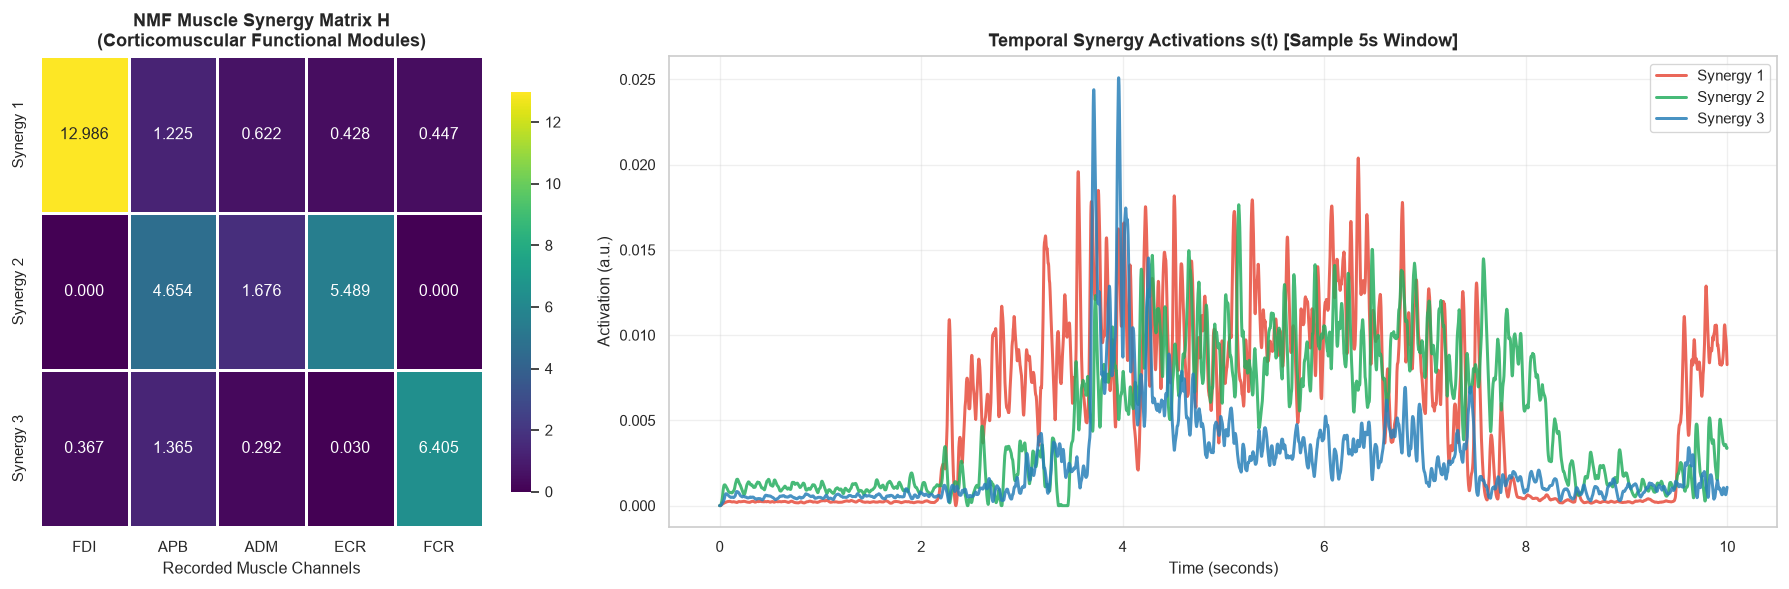

In [8]:
# Visualize H Matrix and Sample Synergy Activations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor="white", gridspec_kw={"width_ratios": [1, 2]})

# 1. Heatmap of H Synergy Mixing Matrix
import seaborn as sns
sns.heatmap(
    H_comp,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=EMG_NAMES,
    yticklabels=[f"Synergy {i+1}" for i in range(n_synergies)],
    ax=ax1,
    cbar_kws={"shrink": 0.85},
    linewidths=0.8,
)
ax1.set_title("NMF Muscle Synergy Matrix H\n(Corticomuscular Functional Modules)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Recorded Muscle Channels")

# 2. Synergy Temporal Dynamics Slice (first 5 seconds = 2500 samples)
t_slice = np.arange(5000) / 500.0
colors = ["#E74C3C", "#27AE60", "#2980B9"]
for syn_i in range(n_synergies):
    ax2.plot(t_slice, W_acts[:5000, syn_i], label=f"Synergy {syn_i+1}", color=colors[syn_i], linewidth=1.8, alpha=0.85)

ax2.set_title("Temporal Synergy Activations s(t) [Sample 5s Window]", fontsize=11, fontweight="bold")
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Activation (a.u.)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [9]:
# ============================================================================
# Cell 4: CORAL-Net Instantiation & NMF Warm-Start Injection
# ============================================================================
# Prepare normalization statistics
emg_all = np.concatenate(train_emgs, axis=0)
kin_all = np.concatenate(train_kins, axis=0)

emg_mean = torch.tensor(emg_all.mean(0), dtype=torch.float32, device=device)
emg_std = torch.clamp(torch.tensor(emg_all.std(0), dtype=torch.float32, device=device), min=1e-6)
kin_mean = torch.tensor(kin_all.mean(0), dtype=torch.float32, device=device)
kin_std = torch.clamp(torch.tensor(kin_all.std(0), dtype=torch.float32, device=device), min=1e-6)

drop_idx = coral_cfg["preprocessing"]["kinematics"]["drop_indices"]
def prepare_batch(eeg, kin, emg):
    eeg = eeg.to(device, non_blocking=True)
    kin = kin.to(device, non_blocking=True)
    emg = emg.to(device, non_blocking=True)
    kn = (kin - kin_mean) / kin_std
    if drop_idx:
        keep = [i for i in range(kn.shape[-1]) if i not in drop_idx]
        kn = kn[..., keep]
    return {"eeg": eeg, "kin": kn}, (emg - emg_mean) / emg_std

# Dimension inference
s_eeg, s_kin, s_emg = train_ds[0]
batch_in, _ = prepare_batch(s_eeg.unsqueeze(0), s_kin.unsqueeze(0), s_emg.unsqueeze(0))
eeg_dim = batch_in["eeg"].shape[-1]
kin_dim = batch_in["kin"].shape[-1]

# Convert NMF components H to torch tensor
H_tensor = torch.from_numpy(H_comp).float()

# Build CORAL-Net with warm-started synergy mixing matrix
coral_model = build_coral_net_from_config(
    coral_cfg,
    input_dim=eeg_dim,
    kin_dim=kin_dim,
    nmf_H=H_tensor,
).to(device)

total_params = sum(p.numel() for p in coral_model.parameters() if p.requires_grad)
print(f"\n[CORAL-Net] Model successfully instantiated on {device}.")
print(f"  • Total trainable parameters: {total_params:,}")
print(f"  • Initial learned delay:     {coral_model.current_lag_ms:.2f} ms")
print(f"  • Synergy mixing matrix initialized from NMF components H.")


[CORAL-Net] Model successfully instantiated on cuda.
  • Total trainable parameters: 1,977,265
  • Initial learned delay:     50.00 ms
  • Synergy mixing matrix initialized from NMF components H.


In [10]:
# ============================================================================
# Cell 5: CORAL-Net Training (Resumable + CLI Progress Bar)
# ============================================================================
coral_loss_fn = build_coral_loss_from_config(coral_cfg).to(device)

train_loader = DataLoader(
    train_ds,
    batch_size=coral_cfg["training"]["batch_size"],
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=coral_cfg["training"]["batch_size"],
    shuffle=False,
)

coral_train_cfg = CORALTrainConfig(
    epochs=coral_cfg["training"]["epochs"],
    lr=coral_cfg["training"]["lr"],
    weight_decay=coral_cfg["training"]["weight_decay"],
    grad_clip_norm=coral_cfg["training"]["grad_clip_norm"],
    use_amp=coral_cfg["training"]["use_amp"],
    checkpoint_dir="outputs/coral_checkpoints",
    checkpoint_every=1,
    early_stop_patience=coral_cfg["training"]["early_stop_patience"],
    resume=True,
    device=str(device),
)


In [11]:
trainer = CORALTrainer(
    model=coral_model,
    criterion=coral_loss_fn,
    prepare_batch=prepare_batch,
    config=coral_train_cfg,
)

print(f"\n--- TRAINING CORAL-NET ({coral_train_cfg.epochs} EPOCHS) ---")
print(f"  • Train windows: {len(train_ds)} | Val windows: {len(val_ds)}")
print(f"  • Checkpoints:   {coral_train_cfg.checkpoint_dir} (last.pt & best.pt)")
print(f"  • Resume:        {coral_train_cfg.resume}")
print(f"  • Device:        {coral_train_cfg.device} | AMP: {coral_train_cfg.use_amp}")

train_result = trainer.train(train_loader, val_loader, verbose=True)


--- TRAINING CORAL-NET (50 EPOCHS) ---
  • Train windows: 3810 | Val windows: 997
  • Checkpoints:   outputs/coral_checkpoints (last.pt & best.pt)
  • Resume:        True
  • Device:        cuda | AMP: True

[INIT] Starting fresh training run (checkpoints -> outputs\coral_checkpoints)



Epoch 01/50 [Train]:   0%|          | 0/119 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 500.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 8.26 GiB is allocated by PyTorch, and 60.09 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Print formatted publication metrics summary report
print(train_result.summary())

# Plot Training History & Delay Trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), facecolor="white")

ax1.plot(train_result.history["epoch"], train_result.history["train_loss"], label="Train Loss", color="#8E44AD", linewidth=2)
ax1.plot(train_result.history["epoch"], train_result.history["val_loss"], label="Val Loss", color="#E67E22", linewidth=2, linestyle="--")
ax1.plot(train_result.history["epoch"], train_result.history["ccc"], label="CCC Loss (1 - CCC)", color="#2980B9", linestyle=":")
ax1.plot(train_result.history["epoch"], train_result.history["pearson"], label="Pearson Loss (1 - r)", color="#27AE60", linestyle="-.")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("CORAL-Net Loss Dynamics", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(train_result.history["epoch"], train_result.history["learned_lag_ms"], color="#D35400", linewidth=2.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Conduction Delay (ms)")
ax2.set_title("Learned Corticospinal Delay $\\tau$ (ms)", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# Cell 6: Test Evaluation, Publication Metrics & Interpretability Dashboard
# ============================================================================
test_ds = WAYEEGDataset(
    data_dir=ROOT / coral_cfg["data"]["data_root"],
    participants=[1],
    split="test",
    window_size=coral_cfg["data"]["window_size"],
    stride=coral_cfg["data"]["stride"],
    latency_shift_ms=0.0,
    preprocess_fn=make_preprocess_fn(coral_cfg),
    cache_dir=ROOT / coral_cfg["data"]["cache_dir"],
)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

coral_model.eval()
P_test, Y_test = collect_predictions(
    coral_model,
    test_loader,
    prepare_batch,
    device,
    n_channels=5,
    use_amp=coral_cfg["training"]["use_amp"],
)

# Compute full evaluation metric suite
metrics = compute_metrics(P_test, Y_test, channel_names=EMG_NAMES)
print("\n" + "="*65)
print("              CORAL-NET PUBLICATION EVALUATION TABLE")
print("="*65)
print(metrics.as_table())
print("="*65 + "\n")

# Continuous Window Overlay Plot (First 5 seconds = 2500 samples)
raw_eeg_test, raw_kin_test, raw_emg_test, _ = test_ds._windows[0]
slice_len = 2500
in_test, tgt_norm = prepare_batch(
    torch.tensor(raw_eeg_test[:slice_len]).unsqueeze(0),
    torch.tensor(raw_kin_test[:slice_len]).unsqueeze(0),
    torch.tensor(raw_emg_test[:slice_len]).unsqueeze(0),
)

with torch.no_grad():
    pred_test, syn_test = coral_model(in_test["eeg"], in_test["kin"], return_synergies=True)

# Unnormalize back to physical scale
pred_phys = (pred_test[0].cpu() * emg_std.cpu() + emg_mean.cpu()).numpy()
true_phys = (tgt_norm[0].cpu() * emg_std.cpu() + emg_mean.cpu()).numpy()
syn_phys = syn_test[0].cpu().numpy()

time_axis = np.arange(slice_len) / 500.0

fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True, facecolor="white")

# Muscles 1 to 5
for ch_idx, ch_name in enumerate(EMG_NAMES):
    ax = axes[ch_idx]
    ax.plot(time_axis, true_phys[:, ch_idx], label="Ground Truth", color="black", linewidth=1.5, alpha=0.7)
    ax.plot(time_axis, pred_phys[:, ch_idx], label="CORAL-Net Predicted", color="#E74C3C", linewidth=1.8)
    ax.set_ylabel(ch_name, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)
    if ch_idx == 0:
        ax.legend(loc="upper right")
        ax.set_title("Continuous EMG Prediction vs. Ground Truth (Physical Scale)", fontsize=12, fontweight="bold")

# Subplot 6: Extracted Cortical Synergies s(t)
ax_syn = axes[5]
for s_idx in range(3):
    ax_syn.plot(time_axis, syn_phys[:, s_idx], label=f"Synergy {s_idx+1}", linewidth=1.5)
ax_syn.set_ylabel("Synergies", fontsize=10, fontweight="bold")
ax_syn.set_xlabel("Time (seconds)", fontsize=11)
ax_syn.grid(True, alpha=0.3)
ax_syn.legend(loc="upper right")
ax_syn.set_title("Predicted Cortical Muscle Synergy Activations $s(t) \\ge 0$", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()